# Generative Model for Molecule Design — VAE vs Transformer vs Latent Diffusion

This Colab-ready notebook trains **three molecule generators** on a public SMILES dataset and evaluates them with:
- validity
- uniqueness
- novelty
- diversity
- QED
- Lipinski pass rate

## Models
1. **GRU VAE** on SMILES
2. **Decoder-only Transformer** on SMILES
3. **Latent Diffusion** over the VAE latent space

## Practical note
This notebook is designed to be **feasible on Colab**. The diffusion model here is a **lightweight latent diffusion prototype**, not a large production-grade chemistry diffusion system.

## Recommended public datasets

For this task, the best public datasets are:

- **MOSES**: a standard benchmark for molecular generation, built from a filtered ZINC Clean Leads collection and designed specifically for benchmarking molecule generators.
- **GuacaMol**: an open benchmark suite for de novo molecular design.
- **QM9**: public and useful, but it is often more naturally used for **property prediction** and 3D tasks than for simple SMILES-only generation.

This notebook defaults to **MOSES if available**, and falls back to a smaller public DeepChem dataset if needed.

In [ ]:
# Cell 1: Install dependencies
!pip -q install rdkit pandas matplotlib scikit-learn requests tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 40.1 MB/s eta 0:00:00


In [ ]:
# Cell 2: Imports
import os
import math
import random
import json
from dataclasses import dataclass
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw, QED, Lipinski, Descriptors

In [ ]:
# Cell 3: Reproducibility and device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# Cell 4: Config
CFG = {
    # Dataset
    "dataset_name": "moses",   # "moses", "delaney", or "custom_csv"
    "custom_csv_path": "/content/smiles.csv",  # used only if dataset_name == "custom_csv"
    "custom_csv_column": "smiles",
    "max_train_smiles": 40000,  # reduce/increase for speed vs quality
    "max_eval_smiles": 5000,
    "max_len": 80,
    "min_smiles_len": 5,
    "batch_size": 128,

    # Training
    "vae_epochs": 8,
    "transformer_epochs": 8,
    "diffusion_epochs": 8,
    "lr": 3e-4,

    # Model sizes
    "emb_dim": 128,
    "hidden_dim": 256,
    "latent_dim": 64,
    "num_layers": 2,
    "transformer_d_model": 192,
    "transformer_nhead": 6,
    "transformer_layers": 4,
    "transformer_ff_dim": 384,
    "dropout": 0.1,

    # Generation
    "num_generate": 2000,
    "temperature": 1.0,
    "top_k": 20,

    # Diffusion
    "diffusion_steps": 100,
}
print(json.dumps(CFG, indent=2))

{
  "dataset_name": "moses",
  "custom_csv_path": "/content/smiles.csv",
  "custom_csv_column": "smiles",
  "max_train_smiles": 40000,
  "max_eval_smiles": 5000,
  "max_len": 80,
  "min_smiles_len": 5,
  "batch_size": 128,
  "vae_epochs": 8,
  "transformer_epochs": 8,
  "diffusion_epochs": 8,
  "lr": 0.0003,
  "emb_dim": 128,
  "hidden_dim": 256,
  "latent_dim": 64,
  "num_layers": 2,
  "transformer_d_model": 192,
  "transformer_nhead": 6,
  "transformer_layers": 4,
  "transformer_ff_dim": 384,
  "dropout": 0.1,
  "num_generate": 2000,
  "temperature": 1.0,
  "top_k": 20,
  "diffusion_steps": 100
}


In [ ]:
# Cell 5: Dataset loaders + helpers
import requests

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return None

MOSES_URLS = {
    "train": "https://media.githubusercontent.com/media/molecularsets/moses/master/data/train.csv",
    "test": "https://media.githubusercontent.com/media/molecularsets/moses/master/data/test.csv",
    "test_scaffolds": "https://media.githubusercontent.com/media/molecularsets/moses/master/data/test_scaffolds.csv",
}

def _read_moses_csv(path_or_url):
    df = pd.read_csv(path_or_url)
    smiles_col = None
    for c in ["SMILES", "smiles"]:
        if c in df.columns:
            smiles_col = c
            break
    if smiles_col is None:
        raise ValueError(f"Could not find a SMILES column. Columns found: {list(df.columns)}")
    return df[smiles_col].dropna().astype(str).tolist()

def load_moses_smiles(local_cache_dir="/content/moses_data", split="train"):
    local_cache_dir = Path(local_cache_dir)
    local_cache_dir.mkdir(parents=True, exist_ok=True)

    if split == "all":
        split_list = ["train", "test", "test_scaffolds"]
    else:
        if split not in MOSES_URLS:
            raise ValueError(f"Unknown split: {split}")
        split_list = [split]

    all_smiles = []
    for s in split_list:
        local_path = local_cache_dir / f"{s}.csv"
        if local_path.exists():
            all_smiles.extend(_read_moses_csv(local_path))
            continue

        url = MOSES_URLS[s]
        print(f"Downloading MOSES {s} split...")
        response = requests.get(url, timeout=120)
        response.raise_for_status()
        local_path.write_bytes(response.content)
        all_smiles.extend(_read_moses_csv(local_path))

    return all_smiles, f"MOSES official CSV(s): {', '.join(split_list)}"

def load_custom_csv(path, column):
    df = pd.read_csv(path)
    return df[column].dropna().astype(str).tolist(), f"custom CSV: {path}"

def clean_smiles_list(smiles_list, min_len=5, max_len=80, max_n=None, seed=42):
    cleaned = []
    seen = set()
    for s in tqdm(smiles_list):
        c = canonicalize_smiles(s)
        if c is None:
            continue
        if not (min_len <= len(c) <= max_len - 2):  # leave room for BOS/EOS
            continue
        if c not in seen:
            cleaned.append(c)
            seen.add(c)
    if max_n is not None and len(cleaned) > max_n:
        rng = random.Random(seed)
        rng.shuffle(cleaned)
        cleaned = cleaned[:max_n]
    return cleaned

def load_smiles_dataset():
    dataset_name = CFG["dataset_name"].lower()
    if dataset_name == "moses":
        train_raw, _ = load_moses_smiles(split="train")
        test_raw, _ = load_moses_smiles(split="test")
        scaffold_raw, _ = load_moses_smiles(split="test_scaffolds")

        train_smiles = clean_smiles_list(
            train_raw,
            min_len=CFG["min_smiles_len"],
            max_len=CFG["max_len"],
            max_n=CFG["max_train_smiles"] + CFG["max_eval_smiles"],
            seed=SEED,
        )
        rng = random.Random(SEED)
        rng.shuffle(train_smiles)
        val_smiles = train_smiles[:CFG["max_eval_smiles"]]
        train_smiles = train_smiles[CFG["max_eval_smiles"]:]
        test_smiles = clean_smiles_list(
            test_raw,
            min_len=CFG["min_smiles_len"],
            max_len=CFG["max_len"],
            max_n=CFG["max_eval_smiles"],
            seed=SEED,
        )
        scaffold_smiles = clean_smiles_list(
            scaffold_raw,
            min_len=CFG["min_smiles_len"],
            max_len=CFG["max_len"],
            max_n=CFG["max_eval_smiles"],
            seed=SEED,
        )
        return train_smiles, val_smiles, test_smiles, scaffold_smiles, "MOSES official CSVs"

    if dataset_name == "custom_csv":
        raw_smiles, source = load_custom_csv(CFG["custom_csv_path"], CFG["custom_csv_column"])
        clean = clean_smiles_list(
            raw_smiles,
            min_len=CFG["min_smiles_len"],
            max_len=CFG["max_len"],
            max_n=CFG["max_train_smiles"] + 2 * CFG["max_eval_smiles"],
            seed=SEED,
        )
        rng = random.Random(SEED)
        rng.shuffle(clean)
        train_smiles = clean[:CFG["max_train_smiles"]]
        val_smiles = clean[CFG["max_train_smiles"]:CFG["max_train_smiles"] + CFG["max_eval_smiles"]]
        test_smiles = clean[CFG["max_train_smiles"] + CFG["max_eval_smiles"]:CFG["max_train_smiles"] + 2 * CFG["max_eval_smiles"]]
        scaffold_smiles = test_smiles
        return train_smiles, val_smiles, test_smiles, scaffold_smiles, source

    raise ValueError("Unknown dataset_name")


In [ ]:
# Cell 6: Load data, build tokenizer, create dataloaders
train_smiles, val_smiles, test_smiles, scaffold_smiles, source_name = load_smiles_dataset()
print("Loaded source:", source_name)
print("Train:", len(train_smiles), "Val:", len(val_smiles), "Test:", len(test_smiles), "Scaffold:", len(scaffold_smiles))
print("Example:", train_smiles[:5])

SPECIAL_TOKENS = ["<pad>", "<bos>", "<eos>", "<unk>"]
PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN = SPECIAL_TOKENS

charset = sorted(set("".join(train_smiles + val_smiles + test_smiles)))
itos = SPECIAL_TOKENS + charset
stoi = {tok: idx for idx, tok in enumerate(itos)}

pad_id = stoi[PAD_TOKEN]
bos_id = stoi[BOS_TOKEN]
eos_id = stoi[EOS_TOKEN]
unk_id = stoi[UNK_TOKEN]
vocab_size = len(itos)

print("Vocab size:", vocab_size)

def encode_smiles(smiles, max_len=None):
    if max_len is None:
        max_len = CFG["max_len"]
    ids = [bos_id] + [stoi.get(ch, unk_id) for ch in smiles] + [eos_id]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids += [pad_id] * (max_len - len(ids))
    return ids

def decode_tokens(ids):
    chars = []
    for idx in ids:
        tok = itos[int(idx)]
        if tok == EOS_TOKEN:
            break
        if tok in SPECIAL_TOKENS:
            continue
        chars.append(tok)
    return "".join(chars)

class SmilesDataset(Dataset):
    def __init__(self, smiles_list):
        self.smiles_list = smiles_list
        self.tokens = [torch.tensor(encode_smiles(s), dtype=torch.long) for s in smiles_list]

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):
        return {"tokens": self.tokens[idx], "smiles": self.smiles_list[idx]}

train_ds = SmilesDataset(train_smiles)
val_ds = SmilesDataset(val_smiles)
test_ds = SmilesDataset(test_smiles)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False)
test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False)

batch = next(iter(train_loader))
print(batch["tokens"].shape)


  0%|          | 0/1584663 [00:00<?, ?it/s]

  0%|          | 0/176074 [00:00<?, ?it/s]

  0%|          | 0/176225 [00:00<?, ?it/s]

Loaded source: MOSES official CSVs
Train: 40000 Val: 5000 Test: 5000 Scaffold: 5000
Example: ['CC(NC(=O)Nc1ccc(C(N)=O)cc1)c1ccc(C#N)cc1', 'CN(C)C(=O)CCNC(=O)NC1CCN(c2ccccc2)CC1', 'O=C(NCCc1ccc(F)cc1)Nc1ccncc1', 'CCCCS(=O)(=O)NCC(O)c1ccc2c(c1)OCO2', 'CCOc1ccccc1N1CCN(C(=O)COC)C(C)C1=O']
Vocab size: 29
torch.Size([128, 80])


In [ ]:
# Cell 7: Shared helpers
def mol_from_smiles(smiles):
    try:
        return Chem.MolFromSmiles(smiles)
    except Exception:
        return None

def compute_morgan_fp(mol, radius=2, n_bits=2048):
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)

def lipinski_violations(mol):
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    violations = int(mw > 500) + int(logp > 5) + int(hbd > 5) + int(hba > 10)
    return violations, {"MW": mw, "LogP": logp, "HBD": hbd, "HBA": hba}

@torch.no_grad()
def sample_categorical(logits, temperature=1.0, top_k=None):
    logits = logits / max(temperature, 1e-6)
    if top_k is not None and top_k < logits.shape[-1]:
        values, indices = torch.topk(logits, k=top_k, dim=-1)
        masked = torch.full_like(logits, float("-inf"))
        masked.scatter_(-1, indices, values)
        logits = masked
    probs = F.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1).squeeze(-1)

def mean_pairwise_tanimoto_distance(smiles_list, max_mols=1000):
    smiles_list = list(smiles_list)
    if len(smiles_list) < 2:
        return np.nan
    if len(smiles_list) > max_mols:
        smiles_list = random.sample(smiles_list, max_mols)
    mols = [mol_from_smiles(s) for s in smiles_list]
    mols = [m for m in mols if m is not None]
    if len(mols) < 2:
        return np.nan
    fps = [compute_morgan_fp(m) for m in mols]
    distances = []
    for i in range(len(fps)):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[i + 1:])
        distances.extend([1 - s for s in sims])
    return float(np.mean(distances)) if distances else np.nan


## Model 1 — GRU VAE

In [ ]:
# Cell 8: VAE model
class SmilesVAE(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, latent_dim, num_layers=1, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.encoder = nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

        self.latent_to_hidden = nn.Linear(latent_dim, hidden_dim)
        self.decoder = nn.GRU(
            emb_dim + latent_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.output = nn.Linear(hidden_dim, vocab_size)

    def encode(self, x):
        emb = self.embed(x)
        _, h = self.encoder(emb)
        h_last = h[-1]
        mu = self.mu(h_last)
        logvar = self.logvar(h_last)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode_teacher_forcing(self, x_in, z):
        emb = self.embed(x_in)
        z_rep = z.unsqueeze(1).expand(-1, emb.size(1), -1)
        dec_in = torch.cat([emb, z_rep], dim=-1)
        h0 = self.latent_to_hidden(z).unsqueeze(0).repeat(CFG["num_layers"], 1, 1)
        out, _ = self.decoder(dec_in, h0)
        logits = self.output(out)
        return logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode_teacher_forcing(x[:, :-1], z)
        return logits, mu, logvar

    @torch.no_grad()
    def sample(self, n, max_len, temperature=1.0, top_k=None, z=None):
        self.eval()
        if z is None:
            z = torch.randn(n, CFG["latent_dim"], device=device)
        else:
            z = z.to(device)
            n = z.size(0)

        h = self.latent_to_hidden(z).unsqueeze(0).repeat(CFG["num_layers"], 1, 1)
        x = torch.full((n, 1), bos_id, dtype=torch.long, device=device)
        finished = torch.zeros(n, dtype=torch.bool, device=device)

        for _ in range(max_len - 1):
            emb = self.embed(x[:, -1:])
            z_rep = z.unsqueeze(1)
            dec_in = torch.cat([emb, z_rep], dim=-1)
            out, h = self.decoder(dec_in, h)
            logits = self.output(out[:, -1, :])
            next_tok = sample_categorical(logits, temperature=temperature, top_k=top_k).unsqueeze(1)
            x = torch.cat([x, next_tok], dim=1)
            finished |= next_tok.squeeze(1).eq(eos_id)
            if finished.all():
                break

        return x[:, 1:]

vae = SmilesVAE(
    vocab_size=vocab_size,
    emb_dim=CFG["emb_dim"],
    hidden_dim=CFG["hidden_dim"],
    latent_dim=CFG["latent_dim"],
    num_layers=CFG["num_layers"],
    dropout=CFG["dropout"],
).to(device)

print("VAE params (M):", round(sum(p.numel() for p in vae.parameters()) / 1e6, 3))


VAE params (M): 1.492


VAE epoch 1/8:   0%|          | 0/312 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.4048723889849124, 'val_loss': 0.9483855947852134}


VAE epoch 2/8:   0%|          | 0/312 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.867694137379145, 'val_loss': 0.7907335311174393}


VAE epoch 3/8:   0%|          | 0/312 [00:00<?, ?it/s]

...

{'epoch': 6, 'train_loss': 0.5944675915898421, 'val_loss': 0.5661444529891014}


VAE epoch 7/8:   0%|          | 0/312 [00:00<?, ?it/s]

{'epoch': 7, 'train_loss': 0.5697064344317485, 'val_loss': 0.5597456112504006}


VAE epoch 8/8:   0%|          | 0/312 [00:00<?, ?it/s]

{'epoch': 8, 'train_loss': 0.5486558207716697, 'val_loss': 0.5279073037207127}


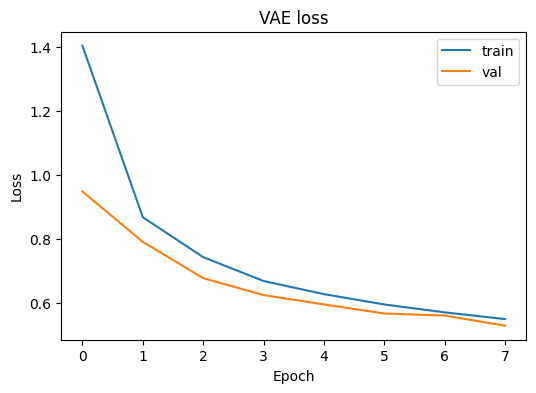

In [ ]:
# Cell 9: VAE training
def vae_loss_fn(logits, target, mu, logvar, beta=0.1):
    recon = F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        target.reshape(-1),
        ignore_index=pad_id,
    )
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kld, recon.item(), kld.item()

@torch.no_grad()
def evaluate_vae(model, loader, beta=0.1):
    model.eval()
    losses = []
    for batch in loader:
        x = batch["tokens"].to(device)
        logits, mu, logvar = model(x)
        loss, _, _ = vae_loss_fn(logits, x[:, 1:], mu, logvar, beta=beta)
        losses.append(loss.item())
    return float(np.mean(losses)) if losses else np.nan

vae_opt = torch.optim.Adam(vae.parameters(), lr=CFG["lr"])
vae_train_hist = []
vae_val_hist = []

for epoch in range(CFG["vae_epochs"]):
    vae.train()
    losses = []
    beta = min(0.2, 0.02 * (epoch + 1))
    pbar = tqdm(train_loader, desc=f"VAE epoch {epoch+1}/{CFG['vae_epochs']}")
    for batch in pbar:
        x = batch["tokens"].to(device)
        logits, mu, logvar = vae(x)
        loss, recon, kld = vae_loss_fn(logits, x[:, 1:], mu, logvar, beta=beta)

        vae_opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
        vae_opt.step()

        losses.append(loss.item())
        pbar.set_postfix(loss=np.mean(losses[-20:]), recon=recon, kld=kld)

    train_loss = float(np.mean(losses))
    val_loss = evaluate_vae(vae, val_loader, beta=beta)
    vae_train_hist.append(train_loss)
    vae_val_hist.append(val_loss)
    print({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss})

plt.figure(figsize=(6, 4))
plt.plot(vae_train_hist, label="train")
plt.plot(vae_val_hist, label="val")
plt.title("VAE loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
# Cell 10: VAE generation
vae_tokens = vae.sample(
    n=CFG["num_generate"],
    max_len=CFG["max_len"],
    temperature=CFG["temperature"],
    top_k=CFG["top_k"],
)
vae_generated_smiles = [decode_tokens(seq.tolist()) for seq in vae_tokens.cpu()]
vae_generated_smiles[:10]


['CC1CN(C)Oc2ccncc2S(=O)(=O)OCC(F)(F)F)n1',
 'CS(=O)(=O)Nc1cccn1CC(=O)NC(C)C',
 'N#Cc1nc(CN2CCN(CCO)CC2)ccc1N1',
 'Cc1nc(Cl)c(SCC(=O)c2cccs2)cs1',
 'CNc1c(C(F)(F)#F)n(CCC)ccc1NC(C)=O',
 'CSc1nc(C(=O)NCCCOCC2CCC2)on1',
 'ClCCc1c(N)nnc1Sc1ccc2c(c1)N=CC2)c1ccccc1',
 'COc1ccc(O)cc1-c1nnc(C(C)C)c1',
 'Nc1cc(Br)ccc1S(=O)(=O)c1ccc(Cl)cc1Oc1ccc2ccccc21',
 'Nc1nnc(-c2cn[nH]c2C)c1C(O)COC']

## Model 2 — Decoder-only Transformer

In [ ]:
# Cell 11: Transformer model
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class SmilesTransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, ff_dim, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos = PositionalEncoding(d_model, max_len=CFG["max_len"])
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def causal_mask(self, seq_len, device):
        return torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1).bool()

    def forward(self, x):
        h = self.embed(x)
        h = self.pos(h)
        mask = self.causal_mask(x.size(1), x.device)
        h = self.encoder(h, mask=mask)
        return self.lm_head(h)

    @torch.no_grad()
    def generate(self, n, max_len, temperature=1.0, top_k=None):
        self.eval()
        x = torch.full((n, 1), bos_id, dtype=torch.long, device=device)
        finished = torch.zeros(n, dtype=torch.bool, device=device)

        for _ in range(max_len - 1):
            logits = self.forward(x)
            next_logits = logits[:, -1, :]
            next_tok = sample_categorical(next_logits, temperature=temperature, top_k=top_k).unsqueeze(1)
            x = torch.cat([x, next_tok], dim=1)
            finished |= next_tok.squeeze(1).eq(eos_id)
            if finished.all():
                break

        return x[:, 1:]

tfm = SmilesTransformerLM(
    vocab_size=vocab_size,
    d_model=CFG["transformer_d_model"],
    nhead=CFG["transformer_nhead"],
    num_layers=CFG["transformer_layers"],
    ff_dim=CFG["transformer_ff_dim"],
    dropout=CFG["dropout"],
).to(device)

print("Transformer params (M):", round(sum(p.numel() for p in tfm.parameters()) / 1e6, 3))


Transformer params (M): 1.199


Transformer epoch 1/8:   0%|          | 0/312 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.2359123459229102, 'val_loss': 0.9002648413181304}


Transformer epoch 2/8:   0%|          | 0/312 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.8843276242797191, 'val_loss': 0.7865806058049202}


Transformer epoch 3/8:   0%|          | 0/312 [00:00<?, ?it/s]

...

{'epoch': 6, 'train_loss': 0.7282635028927754, 'val_loss': 0.6787831977009773}


Transformer epoch 7/8:   0%|          | 0/312 [00:00<?, ?it/s]

{'epoch': 7, 'train_loss': 0.7136508577909225, 'val_loss': 0.6672954514622689}


Transformer epoch 8/8:   0%|          | 0/312 [00:00<?, ?it/s]

{'epoch': 8, 'train_loss': 0.7016732698449721, 'val_loss': 0.6608681991696358}


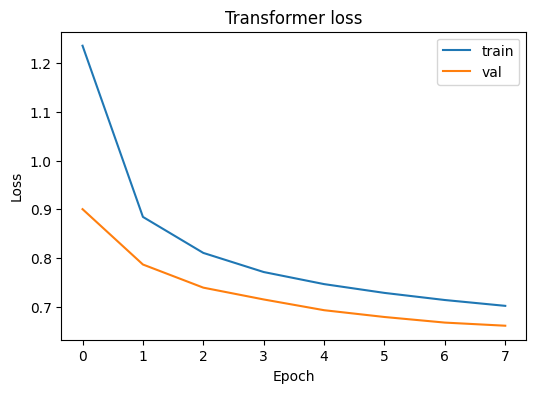

['CN(Cc1ccco1)c1nc(-c2ccc3c(c2)OCO3)no1',
 'Cc1nonc1CNC(=O)c1ccccc1CN1CCNC1=O',
 'CCC(NC(=O)Cn1cccn1)Nc1ccc2ccccc2o1',
 'Cc1ccc2c(Cn3ncc4cccnc43)cccc3c2c1',
 'Brc1ccccc1-c1cncc(N2CC3CC2)c1',
 'COc1ccccc1C(=O)N1CCN(C(=O)N(CC)C(N)=O)CC1',
 'Cc1cc(C)n(CC(=O)Nc2ccccc2)c1Cl',
 'Cc1cccc(-n2nnc(CC)c2S(C)(=O)=O)c1',
 'O=C(CCc1ccccc1Cl)N1CCC(O)C1',
 'c1ccc(F)c(CNc2ncc3onnc3n2)c1C']

In [ ]:
# Cell 12: Transformer training + generation
@torch.no_grad()
def evaluate_transformer(model, loader):
    model.eval()
    losses = []
    for batch in loader:
        x = batch["tokens"].to(device)
        inp = x[:, :-1]
        target = x[:, 1:]
        logits = model(inp)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), target.reshape(-1), ignore_index=pad_id)
        losses.append(loss.item())
    return float(np.mean(losses)) if losses else np.nan

tfm_opt = torch.optim.AdamW(tfm.parameters(), lr=CFG["lr"])
tfm_hist = []
tfm_val_hist = []

for epoch in range(CFG["transformer_epochs"]):
    tfm.train()
    losses = []
    pbar = tqdm(train_loader, desc=f"Transformer epoch {epoch+1}/{CFG['transformer_epochs']}")
    for batch in pbar:
        x = batch["tokens"].to(device)
        inp = x[:, :-1]
        target = x[:, 1:]
        logits = tfm(inp)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), target.reshape(-1), ignore_index=pad_id)

        tfm_opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tfm.parameters(), 1.0)
        tfm_opt.step()

        losses.append(loss.item())
        pbar.set_postfix(loss=np.mean(losses[-20:]))

    train_loss = float(np.mean(losses))
    val_loss = evaluate_transformer(tfm, val_loader)
    tfm_hist.append(train_loss)
    tfm_val_hist.append(val_loss)
    print({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss})

plt.figure(figsize=(6, 4))
plt.plot(tfm_hist, label="train")
plt.plot(tfm_val_hist, label="val")
plt.title("Transformer loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

tfm_tokens = tfm.generate(
    n=CFG["num_generate"],
    max_len=CFG["max_len"],
    temperature=CFG["temperature"],
    top_k=CFG["top_k"],
)
tfm_generated_smiles = [decode_tokens(seq.tolist()) for seq in tfm_tokens.cpu()]
tfm_generated_smiles[:10]


## Model 3 — Latent Diffusion over VAE latents

This uses the trained VAE encoder to produce latent vectors for training molecules, learns a denoising model in latent space, and then decodes sampled latents back into SMILES with the VAE decoder.


In [ ]:
# Cell 13: Build latent dataset from trained VAE
@torch.no_grad()
def encode_dataset_latents(model, loader):
    model.eval()
    zs = []
    for batch in tqdm(loader):
        x = batch["tokens"].to(device)
        mu, logvar = model.encode(x)
        zs.append(mu.cpu())
    return torch.cat(zs, dim=0)

train_latents = encode_dataset_latents(vae, train_loader)
print("Latents:", train_latents.shape)

latent_loader = DataLoader(train_latents, batch_size=CFG["batch_size"], shuffle=True, drop_last=True)


  0%|          | 0/312 [00:00<?, ?it/s]

Latents: torch.Size([39936, 64])


In [ ]:
# Cell 14: Diffusion model
class LatentDiffusionMLP(nn.Module):
    def __init__(self, latent_dim, hidden_dim=256, time_dim=64):
        super().__init__()
        self.time_dim = time_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.net = nn.Sequential(
            nn.Linear(latent_dim + hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def timestep_embedding(self, t, dim):
        half = dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=t.device).float() / max(half, 1))
        args = t[:, None].float() * freqs[None]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb

    def forward(self, x_t, t):
        t_emb = self.timestep_embedding(t, self.time_dim)
        t_h = self.time_mlp(t_emb)
        h = torch.cat([x_t, t_h], dim=-1)
        return self.net(h)

T = CFG["diffusion_steps"]
betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    a_bar = alpha_bars[t].unsqueeze(-1)
    x_t = torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise
    return x_t, noise

diff_model = LatentDiffusionMLP(
    latent_dim=CFG["latent_dim"],
    hidden_dim=CFG["hidden_dim"],
).to(device)
diff_opt = torch.optim.Adam(diff_model.parameters(), lr=CFG["lr"])


Diffusion epoch 1/8:   0%|          | 0/312 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.7099603594113619}


Diffusion epoch 2/8:   0%|          | 0/312 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.40115777861613494}


Diffusion epoch 3/8:   0%|          | 0/312 [00:00<?, ?it/s]

...

{'epoch': 6, 'train_loss': 0.24300595993796983}


Diffusion epoch 7/8:   0%|          | 0/312 [00:00<?, ?it/s]

{'epoch': 7, 'train_loss': 0.24000043431535745}


Diffusion epoch 8/8:   0%|          | 0/312 [00:00<?, ?it/s]

{'epoch': 8, 'train_loss': 0.23627925611650333}


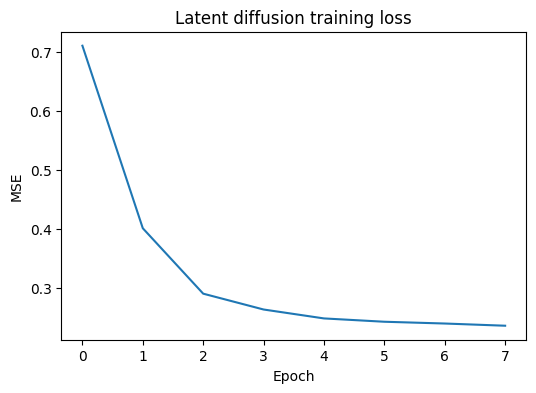

['CN(Cc1cccnc1)C(=O)N1CC(=O)N2CC1CCC1',
 'N=C(Cc1cc2ccc(F)cn2)c1NC(F)(F)CCc1ccccc1',
 'Cc1csc(CNC(=O)CN2C(C)=O)cc1Cl',
 'CCCc1cc(=O)n(C2CC2c2cc(Cl)ccc2C(=O)NC(C)C)c1',
 'O=C(COC(=O)c1[nH]nc(-c2cccc(O)c2)N2CCC(O)C1=O',
 'COc1ccccc1NC(=O)c1ccc2c(c1)NC(=O)c1cccs1',
 'O=C(CCCNC(=O)NC(C)C)C1c1ccccc1',
 'O=C(NCCC(N)=O)NCC(O)c1ccc(F)cc1F',
 'O=c1ccc2c(n1)CC(O)C1(C(F)(F)F)NCC1=O',
 'CC1(C)n2c(nc3ccccc3N2CCOCC2)N1C(=O)CNc1nncn1']

In [ ]:
# Cell 15: Diffusion training + generation
diff_hist = []

for epoch in range(CFG["diffusion_epochs"]):
    diff_model.train()
    losses = []
    pbar = tqdm(latent_loader, desc=f"Diffusion epoch {epoch+1}/{CFG['diffusion_epochs']}")
    for x0 in pbar:
        x0 = x0.to(device)
        t = torch.randint(0, T, (x0.size(0),), device=device)
        x_t, noise = q_sample(x0, t)
        pred = diff_model(x_t, t)
        loss = F.mse_loss(pred, noise)

        diff_opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diff_model.parameters(), 1.0)
        diff_opt.step()

        losses.append(loss.item())
        pbar.set_postfix(loss=np.mean(losses[-20:]))

    diff_hist.append(float(np.mean(losses)))
    print({"epoch": epoch + 1, "train_loss": diff_hist[-1]})

plt.figure(figsize=(6, 4))
plt.plot(diff_hist)
plt.title("Latent diffusion training loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

@torch.no_grad()
def sample_latents_from_diffusion(model, n):
    model.eval()
    x = torch.randn(n, CFG["latent_dim"], device=device)
    for t in reversed(range(T)):
        tt = torch.full((n,), t, device=device, dtype=torch.long)
        eps = model(x, tt)
        alpha = alphas[t]
        alpha_bar = alpha_bars[t]
        beta = betas[t]
        noise = torch.randn_like(x) if t > 0 else torch.zeros_like(x)
        x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * eps) + torch.sqrt(beta) * noise
    return x

diff_latents = sample_latents_from_diffusion(diff_model, CFG["num_generate"])
diff_tokens = vae.sample(
    n=CFG["num_generate"],
    max_len=CFG["max_len"],
    temperature=CFG["temperature"],
    top_k=CFG["top_k"],
    z=diff_latents,
)
diff_generated_smiles = [decode_tokens(seq.tolist()) for seq in diff_tokens.cpu()]
diff_generated_smiles[:10]


## Evaluation

In [ ]:
# Cell 16: Evaluation helpers
def evaluate_generated_smiles(generated_smiles, training_smiles, test_smiles_reference=None):
    records = []
    for s in generated_smiles:
        mol = mol_from_smiles(s)
        canon = Chem.MolToSmiles(mol, canonical=True) if mol is not None else None
        records.append({
            "input_smiles": s,
            "is_valid": mol is not None,
            "canonical_smiles": canon,
            "mol": mol,
        })

    df = pd.DataFrame(records)
    total = len(df)
    valid_df = df[df["is_valid"]].copy()
    valid_canon = valid_df["canonical_smiles"].dropna().tolist()
    unique_valid = sorted(set(valid_canon))
    train_canon = set(filter(None, [canonicalize_smiles(s) for s in training_smiles]))
    test_canon = set(filter(None, [canonicalize_smiles(s) for s in (test_smiles_reference or [])]))
    novel = sorted(set(unique_valid) - train_canon)

    diversity = mean_pairwise_tanimoto_distance(unique_valid, max_mols=1000)

    q_rows = []
    for s in unique_valid:
        mol = mol_from_smiles(s)
        if mol is None:
            continue
        violations, ldict = lipinski_violations(mol)
        q_rows.append({
            "canonical_smiles": s,
            "qed": QED.qed(mol),
            "lipinski_violations": violations,
            "lipinski_pass": violations <= 1,
            **ldict,
        })

    quality_df = pd.DataFrame(q_rows)
    mean_qed = float(quality_df["qed"].mean()) if len(quality_df) else np.nan
    lipinski_pass_rate = float(quality_df["lipinski_pass"].mean()) if len(quality_df) else np.nan
    test_overlap = (
        len([s for s in unique_valid if s in test_canon]) / len(unique_valid)
        if unique_valid and test_canon else np.nan
    )

    summary = {
        "total_generated": total,
        "validity": len(valid_canon) / total if total else 0.0,
        "uniqueness": len(unique_valid) / len(valid_canon) if valid_canon else 0.0,
        "novelty": len(novel) / len(unique_valid) if unique_valid else np.nan,
        "diversity": diversity,
        "mean_qed": mean_qed,
        "lipinski_pass_rate": lipinski_pass_rate,
        "test_overlap": test_overlap,
        "n_unique_valid": len(unique_valid),
    }
    return summary, df.drop(columns=["mol"]), quality_df


In [ ]:
# Cell 17: Evaluate all models
results = {}
details = {}

for name, generated in {
    "vae": vae_generated_smiles,
    "transformer": tfm_generated_smiles,
    "latent_diffusion": diff_generated_smiles,
}.items():
    summary, validity_df, quality_df = evaluate_generated_smiles(
        generated_smiles=generated,
        training_smiles=train_smiles,
        test_smiles_reference=test_smiles,
    )
    results[name] = summary
    details[name] = {
        "validity_df": validity_df,
        "quality_df": quality_df,
    }

results_df = pd.DataFrame(results).T
results_df


Streaming output truncated to the last 5000 lines.
[03:50:08] Explicit valence for atom # 18 C, 5, is greater than permitted
[03:50:08] SMILES Parse Error: ring closure 2 duplicates bond between atom 6 and atom 9 for input: 'COc1ccc(C2(CC)S2(=O)(=O)NCC2c2ccccc2)cc1C'
[03:50:08] Can't kekulize mol.  Unkekulized atoms: 10 11 12 19 20
[03:50:08] Can't kekulize mol.  Unkekulized atoms: 15 16 17 18 19
[03:50:08] SMILES Parse Error: unclosed ring for input: 'COc1ccc(C(=O)Nc2cccc3c(C)c(=O)[nH]2)cc1F'
[03:50:08] Can't kekulize mol.  Unkekulized atoms: 3 5 6 7 21 22 23
[03:50:08] Can't kekulize mol.  Unkekulized atoms: 2 3 5 6 7
[03:50:08] SMILES Parse Error: unclosed ring for input: 'Clc1ccc(OCC(=O)NC1COc2ccccc2Cl)cc1C'
[03:50:08] SMILES Parse Error: extra open parentheses while parsing: COC(CNC(=O)Nc1c(C(F)(F)F)ccc1Cl
[03:50:08] SMILES Parse Error: check for mistakes around position 4:
[03:50:08] COC(CNC(=O)Nc1c(C(F)(F)F)ccc1Cl
[03:50:08] ~~~^
[03:50:08] SMILES Parse Error: Failed parsing SMI

,total_generated,validity,uniqueness,novelty,diversity,mean_qed,lipinski_pass_rate,test_overlap,n_unique_valid
vae,2000.0,0.3595,0.944367,1.000000,0.872186,0.776510,1.000000,0.0,679.0
transformer,2000.0,0.5965,1.000000,0.999162,0.860857,0.812486,1.000000,0.0,1193.0
latent_diffusion,2000.0,0.4440,1.000000,1.000000,0.872203,0.763594,0.998874,0.0,888.0


,validity,uniqueness,novelty,diversity,mean_qed,lipinski_pass_rate,test_overlap
transformer,0.5965,1.000000,0.999162,0.860857,0.812486,1.000000,0.0
latent_diffusion,0.4440,1.000000,1.000000,0.872203,0.763594,0.998874,0.0
vae,0.3595,0.944367,1.000000,0.872186,0.776510,1.000000,0.0


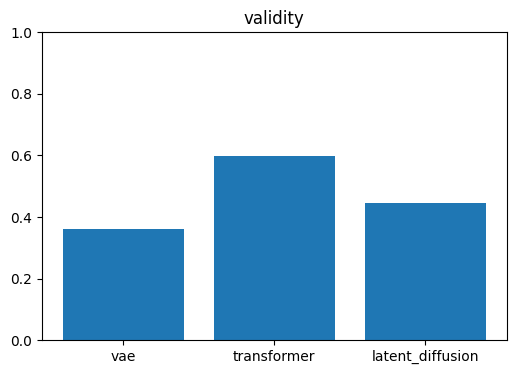

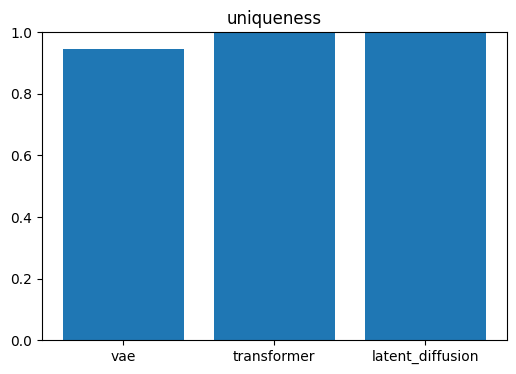

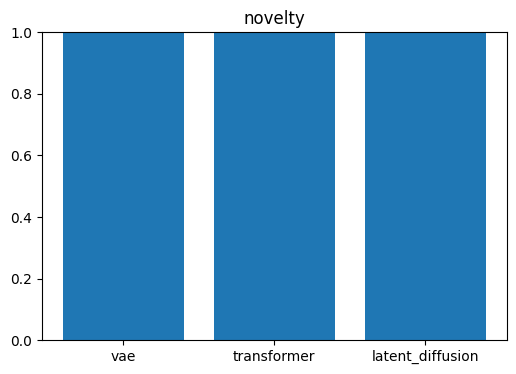

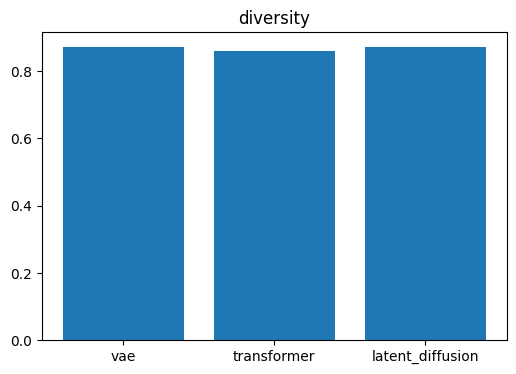

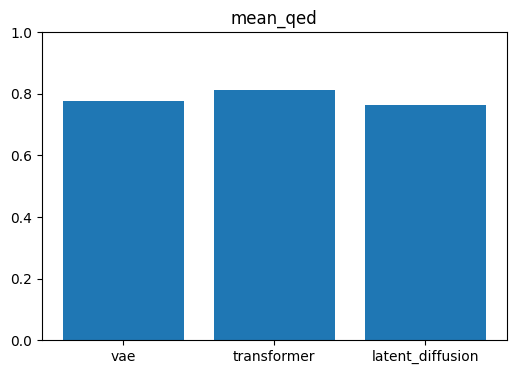

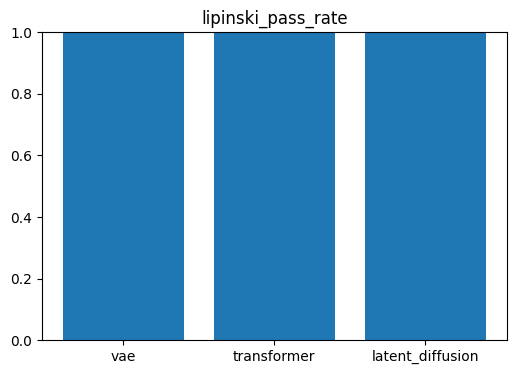

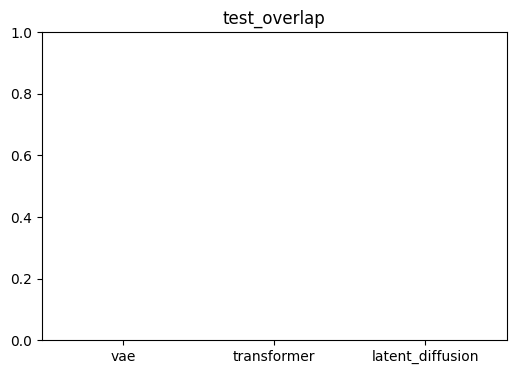

In [ ]:
# Cell 18: Compare models
cols = ["validity", "uniqueness", "novelty", "diversity", "mean_qed", "lipinski_pass_rate", "test_overlap"]
display(results_df[cols].sort_values("validity", ascending=False))

for col in cols:
    plt.figure(figsize=(6, 4))
    plt.bar(results_df.index, results_df[col])
    plt.title(col)
    if col != "diversity":
        plt.ylim(0, 1)
    plt.xticks(rotation=0)
    plt.show()


In [ ]:
# Cell 19: Save outputs
out_dir = Path("/content/molecule_generation_outputs")
out_dir.mkdir(exist_ok=True)

results_df.to_csv(out_dir / "model_comparison_summary.csv", index=True)
pd.DataFrame({"smiles": vae_generated_smiles}).to_csv(out_dir / "vae_generated_smiles.csv", index=False)
pd.DataFrame({"smiles": tfm_generated_smiles}).to_csv(out_dir / "transformer_generated_smiles.csv", index=False)
pd.DataFrame({"smiles": diff_generated_smiles}).to_csv(out_dir / "latent_diffusion_generated_smiles.csv", index=False)

for name, d in details.items():
    d["validity_df"].to_csv(out_dir / f"{name}_validity_details.csv", index=False)
    d["quality_df"].to_csv(out_dir / f"{name}_quality_details.csv", index=False)

print("Saved files to:", out_dir)
sorted([p.name for p in out_dir.iterdir()])[:20]


Saved files to: /content/molecule_generation_outputs


['latent_diffusion_generated_smiles.csv',
 'latent_diffusion_quality_details.csv',
 'latent_diffusion_validity_details.csv',
 'model_comparison_summary.csv',
 'transformer_generated_smiles.csv',
 'transformer_quality_details.csv',
 'transformer_validity_details.csv',
 'vae_generated_smiles.csv',
 'vae_quality_details.csv',
 'vae_validity_details.csv']

Best validity model: transformer


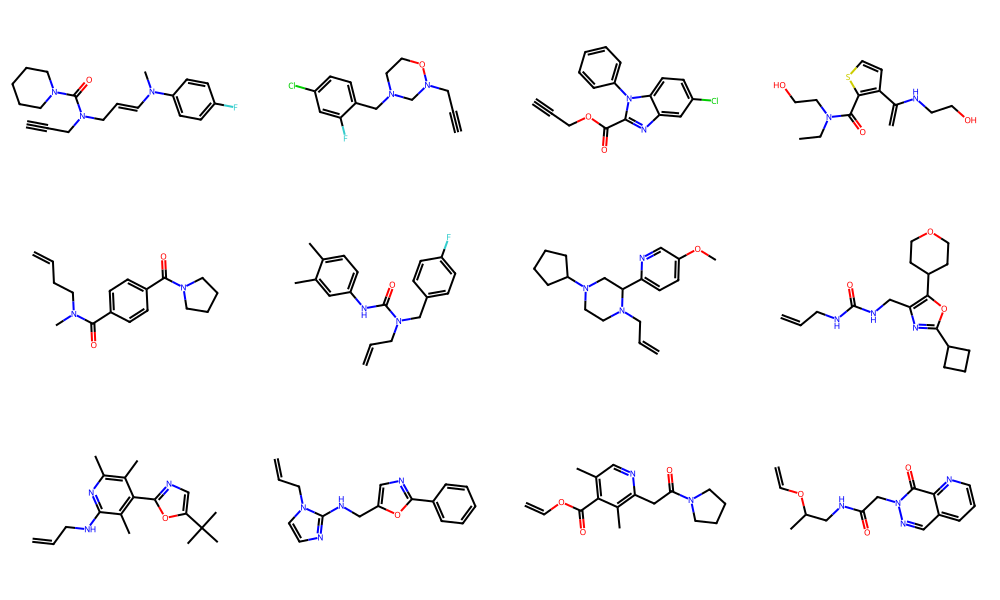

In [ ]:
# Cell 20: Sample molecules from the best-validity model
best_model_name = results_df["validity"].idxmax()
print("Best validity model:", best_model_name)

sample_df = details[best_model_name]["quality_df"].head(12)
sample_smiles = sample_df["canonical_smiles"].tolist()
sample_mols = [mol_from_smiles(s) for s in sample_smiles]
img = Draw.MolsToGridImage([m for m in sample_mols if m is not None], molsPerRow=4, subImgSize=(250, 200))
img


In [ ]:
# Cell 21: Resume-ready bullets
for model_name, row in results_df.iterrows():
    print(
        f"- {model_name}: validity {row['validity']*100:.1f}%, "
        f"uniqueness {row['uniqueness']*100:.1f}%, "
        f"novelty {row['novelty']*100:.1f}%, "
        f"mean QED {row['mean_qed']:.3f}, "
        f"Lipinski pass rate {row['lipinski_pass_rate']*100:.1f}%."
    )


- vae: validity 35.9%, uniqueness 94.4%, novelty 100.0%, mean QED 0.777, Lipinski pass rate 100.0%.
- transformer: validity 59.7%, uniqueness 100.0%, novelty 99.9%, mean QED 0.812, Lipinski pass rate 100.0%.
- latent_diffusion: validity 44.4%, uniqueness 100.0%, novelty 100.0%, mean QED 0.764, Lipinski pass rate 99.9%.


## Observations

**Generative Model for Molecule Design (VAE vs Transformer vs Latent Diffusion)**  
- Implemented and compared three generative approaches for SMILES-based molecular design using the public MOSES benchmark dataset.  
- Built a unified evaluation pipeline for validity, uniqueness, novelty, diversity, QED, and Lipinski pass rate using RDKit.  
- Analyzed trade-offs among model families to compare generation quality, diversity, and drug-likeness.
